In [ ]:
# Core Libraries
import os
import math
import random
import operator
import json
from collections import Counter

# Data Processing
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.spatial.distance import cosine
import scipy

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

# Natural Language Processing (NLP)
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import spacy
import textstat

# Machine Learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    KFold
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Parallelism and Sequence Matching
from difflib import SequenceMatcher

# Sentence Transformers
from sentence_transformers import SentenceTransformer, util

# DEAP (Genetic Programming)
from deap import algorithms, base, creator, tools, gp


In [ ]:
stop_words = set(stopwords.words('english'))
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
lemmatizer = WordNetLemmatizer()
nlp = spacy.load("en_core_web_sm")

c:\Users\FeyiA\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [332]:
# Preprocessing, Embeddings, and Similarity Features
def preprocess_text(text, remove_stopwords=True, apply_lemmatization=True):
    if isinstance(text, str):
        # Lowercase and tokenize
        tokens = word_tokenize(text.lower())
        # Filter out non-alphanumeric tokens
        tokens = [word for word in tokens if word.isalnum()]
        if remove_stopwords:
            tokens = [word for word in tokens if word not in stop_words]
        if apply_lemmatization:
            tokens = [lemmatizer.lemmatize(word) for word in tokens]
        return tokens
    return []

def get_bert_embedding(text):
    return bert_model.encode(text)

def cos_similarity(embedding1, embedding2):
    return 1 - scipy.spatial.distance.cosine(embedding1, embedding2)

def get_similarity(text1, text2):
    embedding1 = get_bert_embedding(text1)
    embedding2 = get_bert_embedding(text2)
    # Cosine similarity
    cosine_sim = cos_similarity(embedding1, embedding2)
    return max(0, cosine_sim)  # Crop negative values



In [333]:
# Features to Extract From Question Pairs
def len_ratio(tokens1, tokens2):
    len1 = len(tokens1)
    len2 = len(tokens2)
    return min(len1, len2) / max(len1, len2) if max(len1, len2) > 0 else 0


def pos_lcs(tokens1, tokens2):
    pos1 = [tag for _, tag in pos_tag(tokens1)]
    pos2 = [tag for _, tag in pos_tag(tokens2)]
    match = SequenceMatcher(None, pos1, pos2).find_longest_match(0, len(pos1), 0, len(pos2))
    lcs_length = match.size
    max_len = max(len(pos1), len(pos2))
    return lcs_length / max_len if max_len > 0 else 0


def pos_jaccard(tokens1, tokens2):
    pos1 = set([tag for _, tag in pos_tag(tokens1)])
    pos2 = set([tag for _, tag in pos_tag(tokens2)])
    intersection = len(pos1.intersection(pos2))
    union = len(pos1.union(pos2))
    return intersection / union if union > 0 else 0


def pos_cosine(tokens1, tokens2):
    pos1 = [tag for _, tag in pos_tag(tokens1)]
    pos2 = [tag for _, tag in pos_tag(tokens2)]
    freq1 = Counter(pos1)
    freq2 = Counter(pos2)
    all_tags = set(freq1.keys()).union(set(freq2.keys()))
    vec1 = np.array([freq1.get(tag, 0) for tag in all_tags])
    vec2 = np.array([freq2.get(tag, 0) for tag in all_tags])
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    return dot_product / (norm1 * norm2) if norm1 > 0 and norm2 > 0 else 0


def dep_sim(tokens1, tokens2):
    doc1 = nlp(" ".join(tokens1))
    doc2 = nlp(" ".join(tokens2))
    deps1 = Counter([token.dep_ for token in doc1])
    deps2 = Counter([token.dep_ for token in doc2])
    all_deps = set(deps1.keys()).union(set(deps2.keys()))
    vec1 = np.array([deps1.get(dep, 0) for dep in all_deps])
    vec2 = np.array([deps2.get(dep, 0) for dep in all_deps])
    if np.linalg.norm(vec1) == 0 or np.linalg.norm(vec2) == 0:
        return 0
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))


def char_ngram(tokens1, tokens2, n=3):
    def ngrams(text, n):
        return set([text[i:i+n] for i in range(len(text) - n + 1)])
    text1 = " ".join(tokens1)
    text2 = " ".join(tokens2)
    ngrams1 = ngrams(text1, n)
    ngrams2 = ngrams(text2, n)
    intersection = ngrams1.intersection(ngrams2)
    union = ngrams1.union(ngrams2)
    return len(intersection) / len(union) if union else 0


def uniq_word_cnt(tokens1, tokens2):
    words1 = set(tokens1)
    words2 = set(tokens2)
    unique_count = len(words1.symmetric_difference(words2))
    union_count = len(words1.union(words2))
    if union_count == 0:
        return 1
    else:
        return 1 - (unique_count / union_count)
    
    
def synonym_similarity(tokens1, tokens2):
    synonyms = lambda word: {lemma.name() for synset in wordnet.synsets(word) for lemma in synset.lemmas()}
    overlap = sum(1 for token in tokens1 if synonyms(token).intersection(tokens2))
    denom = max(len(tokens1), len(tokens2))
    if denom == 0:
        return 0
    return overlap / max(len(tokens1), len(tokens2))


def sequence_alignment(tokens1, tokens2):
    seq_match = SequenceMatcher(None, tokens1, tokens2)
    return seq_match.ratio()


def sentiment_difference_vader(text1, text2):
    analyzer = SentimentIntensityAnalyzer()
    
    sentiment1 = analyzer.polarity_scores(text1)['compound'] 
    sentiment2 = analyzer.polarity_scores(text2)['compound']  

    difference = abs(sentiment1 - sentiment2)
    
    return 1 - (difference / 2)

def extract_features(row):
    tokens1 = preprocess_text(row['question1'])
    tokens2 = preprocess_text(row['question2'])
    text1 = row['question1']
    text2 = row['question2']
    output_vector = [
        len_ratio(tokens1, tokens2),
        pos_lcs(tokens1, tokens2),
        dep_sim(tokens1, tokens2),
        char_ngram(tokens1, tokens2),
        uniq_word_cnt(tokens1, tokens2),
        pos_cosine(tokens1, tokens2),
        pos_jaccard(tokens1, tokens2),
        synonym_similarity(tokens1, tokens2),
        sequence_alignment(tokens1, tokens2),
        sentiment_difference_vader(text1, text2),
    ]
    return output_vector

feature_names = ["len_ratio", "pos_lcs", "dep_sim", "char_ngram", "uniq_cmp", "pos_cos", "pos_jac", "syn_sim", "seq_align", "sent_diff"]

In [334]:
tqdm.pandas()
how_much_to_keep = 0.01
filename = f"final_len_kept_{how_much_to_keep}.pkl"
if os.path.isfile(filename):
    # Load the .pkl file into a DataFrame
    df = pd.read_pickle(filename)
    print("File found and loaded into DataFrame:")
else:
    # Handle the case where the file doesn't exist
    print(f"File '{filename}' does not exist.")
    file_path = os.path.join('data', 'quora_duplicate_questions.csv')
    df = pd.read_csv(file_path)
    num_rows_to_keep = int(len(df) * how_much_to_keep)
    df = df.iloc[:num_rows_to_keep]
    df.dropna(subset=['question1', 'question2'], inplace=True)
    df = df[["is_duplicate", "question1", "question2"]]

    print("Preprocessing Text")
    df['question1_tokens'] = df['question1'].progress_apply(preprocess_text)
    df['question2_tokens'] = df['question2'].progress_apply(preprocess_text)

    print("Extracting Features")
    df['evolve_features'] = df.progress_apply(extract_features, axis=1)

    print("Calculating similarity")
    df['similarity'] = df.progress_apply(lambda row: get_similarity(row['question1'], row['question2']), axis=1)

    print("Creating pickle file")
    df.to_pickle(filename)

display(df)

File found and loaded into DataFrame:


,is_duplicate,question1,question2,question1_tokens,question2_tokens,evolve_features,similarity
0,0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,"[step, step, guide, invest, share, market, india]","[step, step, guide, invest, share, market]","[0.8571428571428571, 0.8571428571428571, 0.993...",0.912277
1,0,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,"[story, kohinoor, diamond]","[would, happen, indian, government, stole, koh...","[0.375, 0.125, 0.14142135623730948, 0.27118644...",0.655141
2,0,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,"[increase, speed, internet, connection, using,...","[internet, speed, increased, hacking, dns]","[0.8333333333333334, 0.3333333333333333, 0.707...",0.515561
3,0,Should I buy tiago?,What keeps childern active and far from phone ...,"[buy, tiago]","[keep, childern, active, far, phone, video, game]","[0.2857142857142857, 0.14285714285714285, 0.42...",0.051699
4,1,How can I be a good geologist?,What should I do to be a great geologist?,"[good, geologist]","[great, geologist]","[1.0, 1.0, 0.9999999999999998, 0.4705882352941...",0.936959
...,...,...,...,...,...,...,...
3445,0,I am a third year MBBS student and I have not ...,Why do people watch movies while travelling?,"[third, year, mbbs, student, gained, knowledge...","[people, watch, movie, travelling]","[0.3333333333333333, 0.16666666666666666, 0.69...",0.020661
3446,0,How do you multiply three matrices?,How do you multiply matrices?,"[multiply, three, matrix]","[multiply, matrix]","[0.6666666666666666, 0.0, 0.40824829046386296,...",0.945009
3447,0,What are some major social faux pas to avoid w...,What are some major social faux pas to avoid w...,"[major, social, faux, pa, avoid, visiting, sur...","[major, social, faux, pa, avoid, visiting, iraq]","[1.0, 1.0, 0.9544271444636666, 0.7391304347826...",0.562804
3448,0,Can I recover iMessages if I deleted them (use...,If I message someone on whatsapp then delete m...,"[recover, imessages, deleted, used, right, cli...","[message, someone, whatsapp, delete, account, ...","[0.6666666666666666, 0.3333333333333333, 0.405...",0.436277


In [335]:
X = df['evolve_features']
Y = df['is_duplicate']
SIMILARITY = df['similarity']

X = X.values
X = np.array([list(example) for example in X])
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

Y = Y.values
SIMILARITY = SIMILARITY.values

X = np.array(X)
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)) # Min Max Scaling

print(f"Shape of X after scaling: {X.shape}")
print(f"Feature range: min={X.min()}, max={X.max()}")

num_samples = len(X)

# train-test split
indices = list(range(num_samples))
train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=42, stratify=Y)

X_train = X[train_indices]
X_test = X[test_indices]
Y_train = Y[train_indices]
Y_test = Y[test_indices]
SIMILARITY_train = SIMILARITY[train_indices]
SIMILARITY_test = SIMILARITY[test_indices]

print(f"Length of X_train: {len(X_train)}")
print(f"Length of X_test: {len(X_test)}")
print(f"Length of Y_train: {len(Y_train)}")
print(f"Length of Y_test: {len(Y_test)}")
print(f"Length of SIMILARITY_train: {len(SIMILARITY_train)}")
print(f"Length of SIMILARITY_test: {len(SIMILARITY_test)}")
print("-"*50)
print(X_train[0])
print(Y_train[0])
print(SIMILARITY_train[0])

Shape of X after scaling: (3450, 10)
Feature range: min=0.0, max=1.0
Length of X_train: 2760
Length of X_test: 690
Length of Y_train: 2760
Length of Y_test: 690
Length of SIMILARITY_train: 2760
Length of SIMILARITY_test: 690
--------------------------------------------------
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
0
0.9199401140213013


In [336]:
class Node:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.prev = None
        self.next = None

class GPCache:
    def __init__(self, max_size=128):
        self.cache = {}
        self.curr_size = 0
        self.hits = 0
        self.misses = 0
        self.max_size = max_size
        self.head = Node(0, 0)
        self.tail = Node(0, 0)
        self.head.next = self.tail
        self.tail.prev = self.head

    def _remove(self, node: Node):
        prev = node.prev
        next = node.next
        prev.next = next
        next.prev = prev

    def _add_to_front(self, node: Node):
        node.prev = self.head
        node.next = self.head.next
        self.head.next.prev = node
        self.head.next = node

    def get(self, key):
        node = self.cache.get(key)
        if node:
            self.hits += 1
            self._remove(node)
            self._add_to_front(node)
            return node.value
        else:
            self.misses += 1
            return None

    def set(self, key, value):
        if key in self.cache:
            node = self.cache[key]
            node.value = value
            self._remove(node)
            self._add_to_front(node)
        else:
            new_node = Node(key, value)
            self.cache[key] = new_node
            self._add_to_front(new_node)
            self.curr_size += 1

            if self.curr_size > self.max_size:
                lru_node = self.tail.prev
                self._remove(lru_node)
                del self.cache[lru_node.key]
                self.curr_size -= 1

    def reset(self):
        self.cache.clear()
        self.hits = 0
        self.misses = 0
        self.curr_size = 0
        self.head.next = self.tail
        self.tail.prev = self.head

    def get_stats(self):
        """Print cache statistics."""
        print("\n")
        print("CACHE STATS------------------")
        print(f"Cache Hits: {self.hits}")
        print(f"Cache Misses: {self.misses}")
        total_calls = self.hits + self.misses
        if total_calls > 0:
            print(f"Cache Hit Rate: {((self.hits) / total_calls) * 100:.2f}%")
        else:
            print("Cache Hit Rate: 0%")
        print(f"Cache Size: {self.curr_size} / {self.max_size}")
        return {"hits": self.hits, "misses": self.misses, "size": self.curr_size}


In [337]:
# Functions to get performance of GP Program
def predicted_threshold_accuracy(similarity_arr, threshold_arr, y_test):
    predicted_labels = [1 if sim >= threshold else 0 for sim, threshold in zip(similarity_arr, threshold_arr)]
    TP = sum((pred == 1 and true == 1) for pred, true in zip(predicted_labels, y_test))
    TN = sum((pred == 0 and true == 0) for pred, true in zip(predicted_labels, y_test))
    FP = sum((pred == 1 and true == 0) for pred, true in zip(predicted_labels, y_test))
    FN = sum((pred == 0 and true == 1) for pred, true in zip(predicted_labels, y_test))
    accuracy = (TP + TN)/len(y_test)
    return accuracy, TP, TN, FP, FN

def specific_threshold_accuracy(similarity_arr, threshold, y_test):
    threshold_predictions = [1 if sim >= threshold else 0 for sim in similarity_arr]
    accuracy = accuracy_score(y_test, threshold_predictions)
    return accuracy

def best_possible_threshold(similarity_arr, y_test, increment = 0.01):
    best_threshold = 0.0
    best_accuracy = 0.0
    for threshold in np.arange(0, 1.01, increment):
        accuracy = specific_threshold_accuracy(similarity_arr, threshold, y_test)
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold
    return best_threshold, best_accuracy

In [338]:
# Potential PSET functions
def s_div(x, y, epsilon=1e-10):
    try:
        if y == 0:
            return 0
        result = x / (y if abs(y) > epsilon else epsilon) #prevent super small division
        return result
    except OverflowError:
        return 0
    

def w_avg(a, b, w=0.5):
    return w * a + (1 - w) * b


def s_log(x):
    try:
        if x > 0:
            return math.log(x)
        else:
            return 0  # Logarithm of non-positive values is undefined
    except ValueError:
        return 0

    
def s_exp(x, cap=1e100):
    try:
        if x > math.log(cap):
            return cap
        return math.exp(x)
    except OverflowError:
        return 0

def s_pow(x, y, cap=1e10):
    # Handle special cases
    if x == 0 and y < 0:
        return 0 
    if x < 0 and not float(y).is_integer():
        return 0  # Negative base with fractional exponent -> NaN
    
    try:
        result = x**y
        return result
    except OverflowError:
        return 0
    except ZeroDivisionError:
        return 0
    
def s_sqrt(x):
    return math.sqrt(x) if x >= 0 else 0

def s_square(x):
    try:
        result = x * x
        return result
    except (OverflowError, ValueError):
        return 0

def s_average(x, y):
    return (x + y) / 2

def s_variance(x, y):
    return (x - y) ** 2

def gt(x, y):
    return 1 if x > y else 0

def lt(x, y):
    return 1 if x < y else 0

def equal_to(x, y):
    return 1 if x == y else 0 
    
def sigmoid(x):
    try:
        if x >= 0:
            # For non-negative x, calculate sigmoid directly to avoid overflow in exp(-x)
            z = math.exp(-x)
            return 1 / (1 + z)
        else:
            # For negative x, reformulate to avoid overflow in exp(x)
            z = math.exp(x)
            return z / (1 + z)
    except OverflowError:
        # Return 0 or 1 for extreme cases
        return 0 if x < 0 else 1


def limit(input, minimum, maximum):
    return min(max(input,minimum), maximum)

def if_else(condition, true_value, false_value):
    return true_value if condition > 0 else false_value

def threshold(value, threshold=0.5):
    return 1.0 if value > threshold else 0.0

def s_round(x):
    if math.isnan(x) or math.isinf(x):
        return 0
    return round(x)

def s_trunc(x):
    if math.isnan(x) or math.isinf(x):
        return 0
    return math.trunc(x)


In [339]:
# DEAP setup
num_features = len(X[0])
print(f"Number of features: {num_features}")

# Primitives
pset = gp.PrimitiveSetTyped("main", [float]*num_features, float)
pset.addPrimitive(operator.add, [float, float], float)
pset.addPrimitive(operator.sub, [float, float], float)
pset.addPrimitive(operator.mul, [float, float], float)
pset.addPrimitive(operator.neg, [float], float)
pset.addPrimitive(s_div, [float, float], float)
pset.addPrimitive(w_avg, [float, float, float], float)
pset.addPrimitive(abs, [float], float)
pset.addPrimitive(min, [float, float], float)
pset.addPrimitive(max, [float, float], float)

# Terminals
pset.addTerminal(0.1, float)
pset.addTerminal(0.5, float)
pset.addTerminal(1.0, float)
pset.addTerminal(np.mean(SIMILARITY_train), float, name="dupe_mean_sim")
pset.addTerminal(np.min(SIMILARITY_train), float, name="dupe_min_sim")
pset.addTerminal(np.max(SIMILARITY_train), float, name="dupe_max_sim")

for i in range(num_features):
    pset.renameArguments(**{f'ARG{i}': f'{feature_names[i]}'})

Number of features: 10


In [340]:
gp_cache = GPCache()

def evolved_threshold(adjustment):
    return np.clip(np.round(adjustment,2), 0, 1)


def recall_prec(TP, FP, FN, TN):
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    return f1, precision, recall, specificity

def evaluate_individual(individual, arg_names, X, Y, SIMILARITY, toolbox):
    k = 5
    cached_value = gp_cache.get(str(individual))
    if cached_value is not None:
        return cached_value
    else:
        # Compile the individual into an executable function
        get_action = toolbox.compile(expr=individual)

        # Penalize solutions that don't use any features
        if not any(arg in str(individual) for arg in arg_names):
            return (0, 1.0e-3)

        kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
        fold_fitness = []

        # for train_index, val_index in kf.split(X):
        for train_index, val_index in kf.split(X, Y):
            # Split data into training and validation sets
            X_train, X_val = X[train_index], X[val_index]
            Y_train, Y_val = Y[train_index], Y[val_index]
            SIMILARITY_train, SIMILARITY_val = SIMILARITY[train_index], SIMILARITY[val_index]

            # Predict thresholds for validation set
            predicted_thresholds = [
                evolved_threshold(get_action(*x)) for x in X_val
            ]
            accuracy, TP, TN, FP, FN = predicted_threshold_accuracy(SIMILARITY_val, predicted_thresholds, Y_val)
            
            
            complexity_penalty = len(individual) * 0.0001
            total_penalty = complexity_penalty
            
            # f1, precision, recall, specificity = recall_prec(TP, FP, FN, TN)

            # Append fold metrics
            fold_fitness.append(accuracy - total_penalty)

        # Calculate mean metrics and variances
        mean_metrics = np.mean(fold_fitness)
        variances = np.var(fold_fitness)

        # Final fitness values
        final_fitness = (
            mean_metrics,
            variances,
        )

        # Cache and return the final fitness
        gp_cache.set(str(individual), final_fitness)
        return final_fitness


In [391]:
# Define fitness function
creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMulti)

# Toolbox configuration
toolbox = base.Toolbox()
toolbox.register("expr", gp.genGrow, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)

# Specify evaluation on X_train and Y_train
toolbox.register("evaluate", evaluate_individual, arg_names=feature_names, X=X_train, Y=Y_train, SIMILARITY=SIMILARITY_train, toolbox=toolbox)
toolbox.register("select", tools.selTournament, tournsize=5)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genHalfAndHalf, min_=0, max_=2)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=7))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=7))
toolbox.register("map", map)

c:\Users\FeyiA\AppData\Local\Programs\Python\Python310\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMulti' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\FeyiA\AppData\Local\Programs\Python\Python310\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [392]:
def runTrials(toolbox, population_size=35, num_generations=50, prob_xover=0.85, 
              prob_mutate=0.15, random_seed=42):
    random.seed(random_seed)
    pop = toolbox.population(n=population_size)
    hof = tools.ParetoFront()
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", np.max, axis=0)
    stats.register("avg", np.mean, axis=0)
    stats.register("min", np.min, axis=0)
    stats.register("std", np.std, axis=0)
    toolbox.register("map", map)

    pop, log = algorithms.eaMuCommaLambda( 
        population=pop,
        toolbox=toolbox,
        mu=population_size,
        lambda_=population_size * 2,
        cxpb=prob_xover,
        mutpb=prob_mutate,
        ngen=num_generations,
        stats=stats,
        halloffame=hof,
        verbose=True,
    )
    return pop, log, hof, stats

In [393]:
pop, log, hof, stats = runTrials(toolbox, population_size=100, num_generations=50, prob_xover = 0.80, prob_mutate = 0.20)

gen	nevals	max                    	avg                            	min                            	std                    
0  	100   	[0.71419275 0.001     ]	[4.26601420e-01 3.30777148e-04]	[0.00000000e+00 5.25099769e-07]	[0.21561562 0.0003668 ]
1  	200   	[0.7170913  0.00088821]	[6.20201565e-01 2.41236085e-04]	[4.68540580e-01 7.87649653e-07]	[0.05122086 0.00021581]
2  	200   	[0.73460725 0.00088821]	[6.58620725e-01 3.42764125e-04]	[5.51873913e-01 7.87649653e-07]	[0.03267831 0.00022831]
3  	200   	[0.73655652 0.00088821]	[6.88573478e-01 3.71266541e-04]	[6.19752174e-01 3.67569838e-05]	[0.02836553 0.00024142]
4  	200   	[0.75032464 0.00088821]	[7.05942159e-01 4.27628124e-04]	[6.39555072e-01 3.46565848e-05]	[0.02610095 0.00022549]
5  	200   	[0.76336812 0.00088821]	[7.19210754e-01 5.21613106e-04]	[6.40904348e-01 7.82398656e-05]	[0.02406651 0.00018604]
6  	200   	[0.76336812 0.00088821]	[7.35244072e-01 5.32831863e-04]	[6.21339130e-01 3.75446335e-05]	[0.02037238 0.00021278]
7  	200   	[0.76

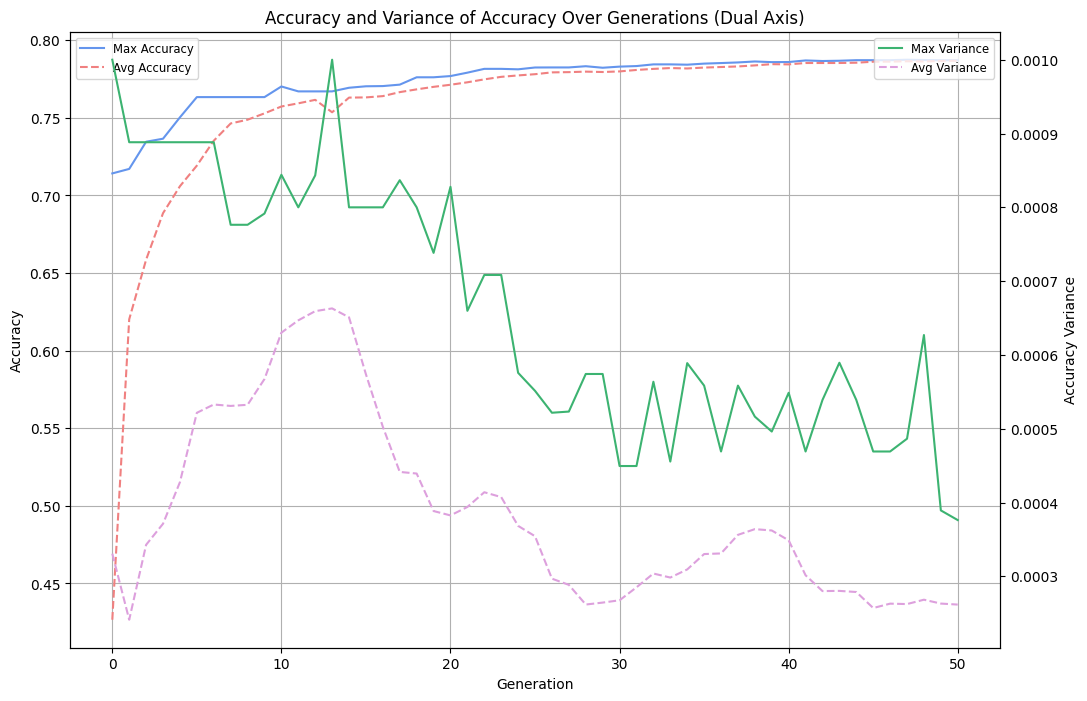

In [394]:
def extract_objective_stats(log, stat_key, objective_index):
    stats = log.select(stat_key)
    return [stat[objective_index] for stat in stats]
  
def plot_accuracy_and_variance_dual_axis(log):
    gen = log.select("gen")
    max_accuracy = extract_objective_stats(log, "max", 0)
    avg_accuracy = extract_objective_stats(log, "avg", 0)

    max_variance = extract_objective_stats(log, "max", 1)
    avg_variance = extract_objective_stats(log, "avg", 1)

    fig, ax1 = plt.subplots(figsize=(12, 8))

    # Plot accuracy on the left y-axis
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Accuracy")
    ax1.plot(gen, max_accuracy, label="Max Accuracy", linestyle='-', color="#6495ED")
    ax1.plot(gen, avg_accuracy, label="Avg Accuracy", linestyle='--', color="#F08080")
    ax1.tick_params(axis="y")
    ax1.legend(loc="upper left", fontsize="small")
    ax1.grid(True)

    # Plot variance on the right y-axis
    ax2 = ax1.twinx()
    ax2.set_ylabel("Accuracy Variance")
    ax2.plot(gen, max_variance, label="Max Variance", linestyle='-', color="#3CB371")
    ax2.plot(gen, avg_variance, label="Avg Variance", linestyle='--', color="#DDA0DD")
    ax2.tick_params(axis="y")
    ax2.legend(loc="upper right", fontsize="small")

    plt.title("Accuracy and Variance of Accuracy Over Generations (Dual Axis)")
    plt.show()

plot_accuracy_and_variance_dual_axis(log)



--------------------------------------------------
Most optimal static threshold is: 0.8 with accuracy 0.7666666666666667
--------------------------------------------------
Best Solutions with Highest Accuracy:
Accuracy: 0.7928 | Length: 29 |Expression: w_avg(dupe_mean_sim, w_avg(w_avg(w_avg(w_avg(max(min(sent_diff, syn_sim), pos_cos), add(pos_cos, max(dupe_mean_sim, pos_cos)), dupe_mean_sim), add(sent_diff, sent_diff), dupe_max_sim), add(abs(uniq_cmp), dep_sim), dupe_mean_sim), dupe_mean_sim, sent_diff), dupe_mean_sim) 
Accuracy: 0.7928 | Length: 29 |Expression: w_avg(dupe_mean_sim, w_avg(w_avg(w_avg(w_avg(max(min(sent_diff, syn_sim), pos_cos), add(pos_cos, max(dupe_mean_sim, pos_cos)), dupe_mean_sim), add(dupe_max_sim, sent_diff), dupe_max_sim), add(abs(uniq_cmp), dep_sim), dupe_mean_sim), dupe_mean_sim, sent_diff), dupe_mean_sim) 
Accuracy: 0.7928 | Length: 23 |Expression: w_avg(dupe_mean_sim, w_avg(w_avg(w_avg(w_avg(max(sent_diff, pos_cos), add(pos_cos, dep_sim), dupe_mean_sim), sy

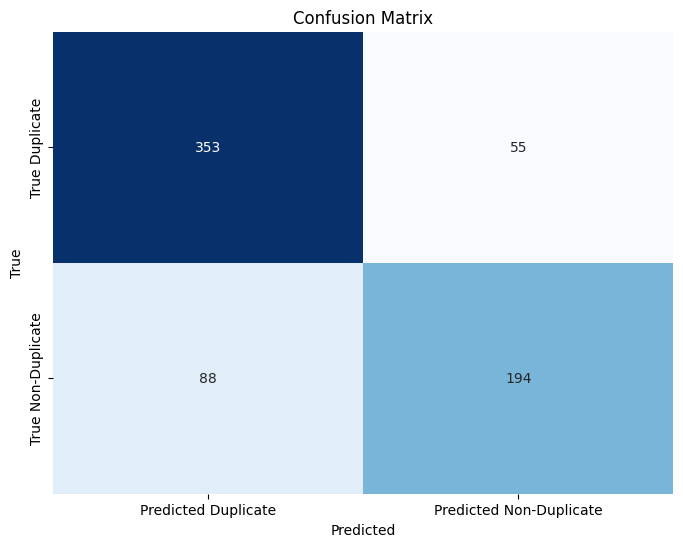

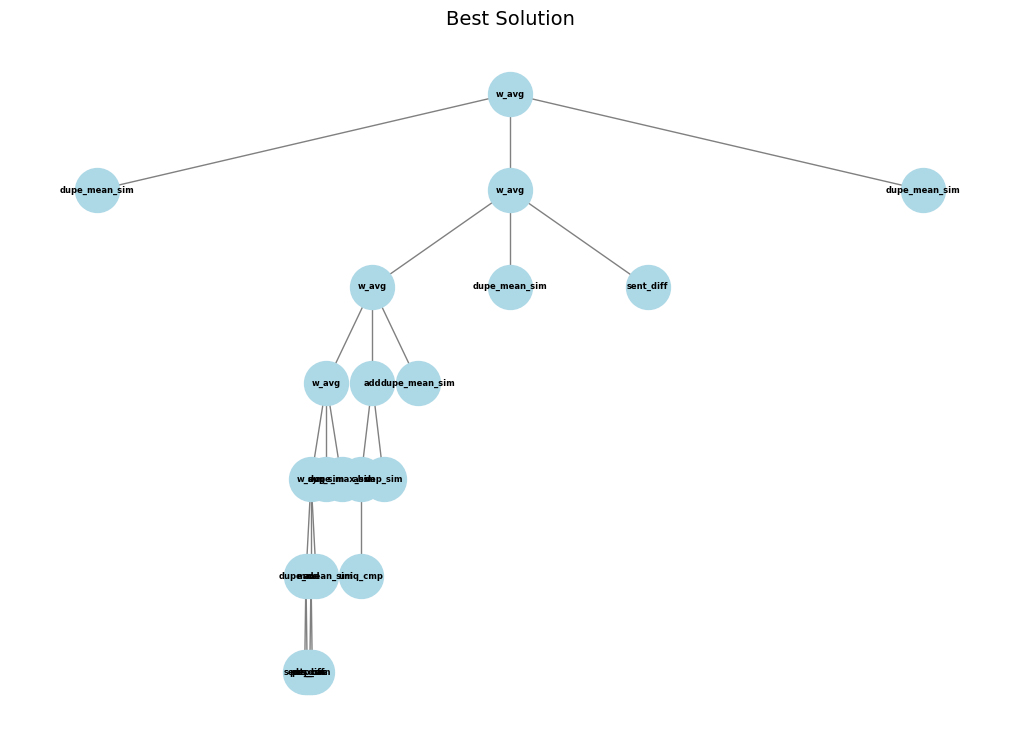

--------------------------------------------------
Threshold Statistics for hof[0]:
Min Threshold: 0.65
Max Threshold: 0.94
Mean Threshold: 0.83
Std Threshold: 0.07
--------------------------------------------------


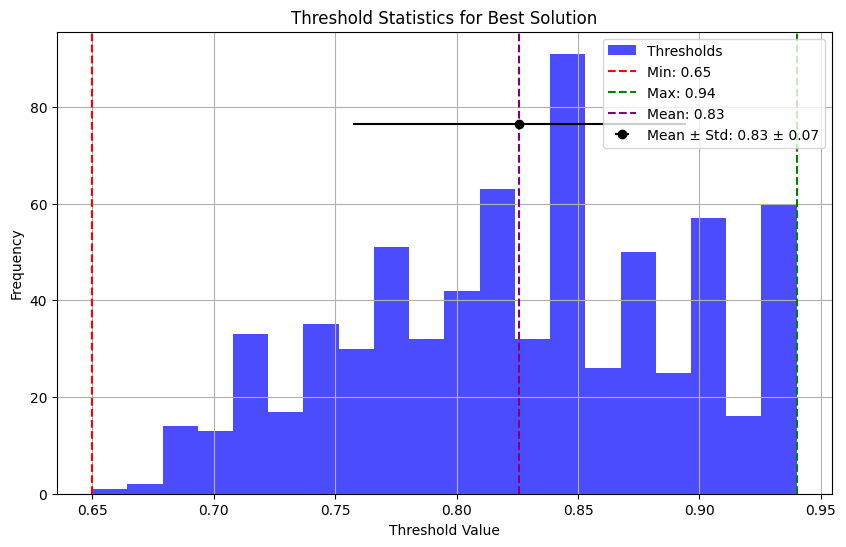

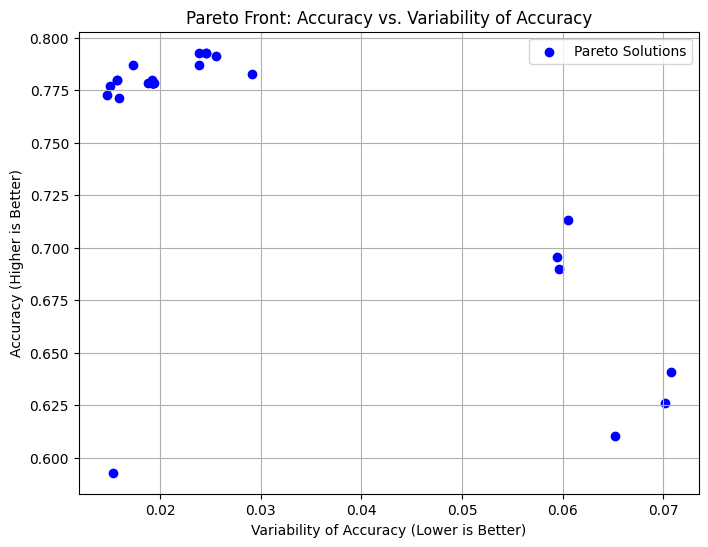

In [427]:
# Evaluate Pareto Solutions
def evaluate_pareto_solutions(hof, X_test, Y_test, SIMILARITY_test, toolbox):
    highest_accuracy = -float("inf")
    best_solutions = []
    solutions_with_accuracy = []
    
    for i, ind in enumerate(hof):
        func = toolbox.compile(expr=ind)
        predicted_thresholds = [evolved_threshold(func(*x)) for x in X_test]
        accuracy, TP, TN, FP, FN = predicted_threshold_accuracy(SIMILARITY_test, predicted_thresholds, Y_test)
        solutions_with_accuracy.append((ind, accuracy, len(ind)))
        # Track the highest accuracy and corresponding solutions
        if accuracy > highest_accuracy:
            highest_accuracy = accuracy
            best_solutions = [(ind, accuracy, len(ind))]  # Reset best solutions list
        elif accuracy == highest_accuracy:
            best_solutions.append((ind, accuracy, len(ind)))

    # Print all solutions with the highest accuracy
    print("Best Solutions with Highest Accuracy:")
    for solution, acc, len_ind in best_solutions[:10]:
        print(f"Accuracy: {acc:.4f} | Length: {len_ind} |Expression: {solution} ")
        
    best_solutions.sort(key=lambda x: x[2], reverse=False)
    return best_solutions
        
def best_pareto_solution(hof, X_test, Y_test, SIMILARITY_test, toolbox):
    best_func = toolbox.compile(expr=hof[0])
    test_threshold_predictions = [evolved_threshold(best_func(*x)) for x in X_test]
    test_acc, TP, TN, FP, FN = predicted_threshold_accuracy(SIMILARITY_test, test_threshold_predictions, Y_test)
    predicted_labels = [1 if sim >= threshold else 0 for sim, threshold in zip(SIMILARITY_test, test_threshold_predictions)]
    print("-"*50)
    print("GP Solution with Best Accuracy and Shortest Length:")
    print(f"Length: {len(hof[0])} | {str(hof[0])}")
    print("Genetic Programming Test Accuracy:", test_acc)
    print(f"Max Threshold: {np.max(test_threshold_predictions)} | Min Threshold: {np.min(test_threshold_predictions)} | Mean Threshold: {np.mean(test_threshold_predictions)} | Std Threshold: {np.std(test_threshold_predictions)}")
    print("-"*50)
    
    # Plot confusion matrix
    plotConfusionMatrix(Y_test, predicted_labels)
    
# def visualize_best_pf_solution(hof):
#     best_individual = hof[0]
#     nodes, edges, labels = gp.graph(best_individual)
#     g = nx.DiGraph()
#     g.add_nodes_from(nodes)
#     g.add_edges_from(edges)

#     # Determine positions for a hierarchical layout
#     def hierarchy_pos(graph, root=0, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None, parent=None):
#         """
#         Recursive function to compute hierarchical positions for a tree.
#         """
#         if pos is None:
#             pos = {root: (xcenter, vert_loc)}
#         else:
#             pos[root] = (xcenter, vert_loc)
#         children = list(graph.neighbors(root))
#         if not isinstance(graph, nx.DiGraph) or parent is None:
#             if parent is not None:
#                 children.remove(parent)
#         if len(children) != 0:
#             dx = width / len(children)
#             nextx = xcenter - width / 2 - dx / 2
#             for child in children:
#                 nextx += dx
#                 pos = hierarchy_pos(graph, child, width=dx, vert_gap=vert_gap, vert_loc=vert_loc - vert_gap, xcenter=nextx, pos=pos, parent=root)
#         return pos

#     # Compute hierarchical positions
#     pos = hierarchy_pos(g)

#     # Draw the graph
#     plt.figure(figsize=(10, 7))  # Adjust figure size for better visibility
#     nx.draw(
#         g,
#         pos,
#         with_labels=True,
#         labels=labels,
#         node_size=1000,
#         node_color="lightblue",
#         font_size=6,
#         font_weight="bold",
#         edge_color="gray",
#         arrows=False,  # Hide arrows for a cleaner look
#     )
#     plt.title("Best Solution", fontsize=14)
#     plt.show()

def visualize_best_pf_solution(hof):
    best_individual = hof[0]
    nodes, edges, labels = gp.graph(best_individual)

    # Create the graph
    g = nx.Graph()
    g.add_nodes_from(nodes)
    g.add_edges_from(edges)

    # Use spring layout with a higher k value for increased spacing
    pos = nx.spring_layout(g, seed=42, k=0.7) 

    # Draw nodes
    nx.draw_networkx_nodes(
        g, 
        pos, 
        node_size=1200, 
        node_color="lightblue", 
        alpha=0.9
    )

    # Draw edges
    nx.draw_networkx_edges(
        g, 
        pos, 
        edge_color="gray", 
        width=1.5, 
        alpha=0.8
    )

    # Draw labels inside the nodes
    nx.draw_networkx_labels(
        g, 
        pos, 
        labels=labels, 
        font_size=9,
        font_color="black", 
        font_weight="regular"
    )

    # Set the title
    plt.title("Best Solution", fontsize=16)
    plt.axis("off")
    plt.show()


def plotThresholdAccuracy(SIMILARITY_test, Y_test):
    thresholds = np.linspace(0, 1, 100)  # Thresholds from 0 to 1
    accuracies = [specific_threshold_accuracy(SIMILARITY_test, t, Y_test) for t in thresholds]
    custom_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
    custom_accuracies = [specific_threshold_accuracy(SIMILARITY_test, t, Y_test) for t in custom_thresholds]
    best_threshold, best_accuracy = best_possible_threshold(SIMILARITY_test, Y_test)
    
    print("-"*50)
    print(f"Most optimal static threshold is: {best_threshold} with accuracy {best_accuracy}")
    print("-"*50)
    
def plotConfusionMatrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Predicted Duplicate', 'Predicted Non-Duplicate'],
                yticklabels=['True Duplicate', 'True Non-Duplicate'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    
def visualize_threshold_statistics(hof, X_test, toolbox):
    best_func = toolbox.compile(expr=hof[0])
    thresholds = [evolved_threshold(best_func(*x)) for x in X_test]

    thresholds = np.array(thresholds)
    
    aggregate_min = np.min(thresholds)
    aggregate_max = np.max(thresholds)
    aggregate_mean = np.mean(thresholds)
    aggregate_std = np.std(thresholds)

    print("-" * 50)
    print(f"Threshold Statistics for hof[0]:")
    print(f"Min Threshold: {aggregate_min:.2f}")
    print(f"Max Threshold: {aggregate_max:.2f}")
    print(f"Mean Threshold: {aggregate_mean:.2f}")
    print(f"Std Threshold: {aggregate_std:.2f}")
    print("-" * 50)

    plt.figure(figsize=(10, 6))

    plt.hist(thresholds, bins=20, alpha=0.7, label='Thresholds', color='blue')

    plt.axvline(aggregate_min, color='red', linestyle='--', label=f'Min: {aggregate_min:.2f}')
    plt.axvline(aggregate_max, color='green', linestyle='--', label=f'Max: {aggregate_max:.2f}')
    plt.axvline(aggregate_mean, color='purple', linestyle='--', label=f'Mean: {aggregate_mean:.2f}')

    plt.errorbar(
        x=aggregate_mean,
        y=0.8 * plt.gca().get_ylim()[1],
        xerr=aggregate_std,
        fmt='o',
        color='black',
        label=f'Mean ± Std: {aggregate_mean:.2f} ± {aggregate_std:.2f}'
    )

    # Add labels and legend
    plt.xlabel('Threshold Value')
    plt.ylabel('Frequency')
    plt.title('Threshold Statistics for Best Solution')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()



def visualize_pareto_front(hof, accuracies, variabilities):
    plt.figure(figsize=(8, 6))
    plt.scatter(variabilities, accuracies, color='blue', label='Pareto Solutions')

    plt.scatter([variabilities[0]], [accuracies[0]], color='red', label='Best Solution', zorder=5)

    plt.xlabel('Variability of Accuracy (Lower is Better)')
    plt.ylabel('Accuracy (Higher is Better)')
    plt.title('Pareto Front: Accuracy vs. Variability of Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    
def extract_thresholds_and_accuracies(hof, X_test, Y_test, SIMILARITY_test, toolbox):
    thresholds_all = []
    accuracies = []
    variabilities = []
    
    for solution in hof:
        func = toolbox.compile(expr=solution)
        
        thresholds = [evolved_threshold(func(*x)) for x in X_test]
        thresholds_all.append(thresholds)
        
        test_acc, TP, TN, FP, FN = predicted_threshold_accuracy(SIMILARITY_test, thresholds, Y_test)
        accuracies.append(test_acc)
        
        fold_accuracies = [specific_threshold_accuracy(SIMILARITY_test, t, Y_test) for t in thresholds]
        variabilities.append(np.std(fold_accuracies))
    
    return np.array(thresholds_all), accuracies, variabilities


def visualize_pareto_front(accuracies, variabilities):
    plt.figure(figsize=(8, 6))
    plt.scatter(variabilities, accuracies, color='blue', label='Pareto Solutions')
    plt.xlabel('Variability of Accuracy (Lower is Better)')
    plt.ylabel('Accuracy (Higher is Better)')
    plt.title('Pareto Front: Accuracy vs. Variability of Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    
def visualize_threshold_similarity_correlation(SIMILARITY_test, thresholds_all):
    plt.figure(figsize=(8, 6))
    thresholds_mean = np.mean(thresholds_all, axis=0)
    plt.scatter(SIMILARITY_test, thresholds_mean, alpha=0.7, color='blue', label='Mean Thresholds')
    
    z = np.polyfit(SIMILARITY_test, thresholds_mean, 1)
    p = np.poly1d(z)
    plt.plot(SIMILARITY_test, p(SIMILARITY_test), color='red', linestyle='--', label='Trend Line')

    plt.xlabel('Similarity Score')
    plt.ylabel('Threshold Value')
    plt.title('Thresholds vs. Similarity Scores')
    plt.legend()
    plt.grid(True)
    plt.show()



thresholds_all, accuracies, variabilities = extract_thresholds_and_accuracies(hof, X_test, Y_test, SIMILARITY_test, toolbox)
visualize_pareto_front(accuracies, variabilities)
plotThresholdAccuracy(SIMILARITY_test, Y_test)
solutions_with_accuracy = evaluate_pareto_solutions(hof, X_test, Y_test, SIMILARITY_test, toolbox)
hof_updated = [sol for (sol, acc, len_ind) in solutions_with_accuracy]
best_pareto_solution(hof_updated, X_test, Y_test, SIMILARITY_test, toolbox)
visualize_best_pf_solution(hof_updated)
visualize_threshold_statistics(hof_updated, X_test, toolbox)

In [397]:
# Evaluate best GP Solution against other classifiers

# Decision Tree Classifier
def train_and_evaluate_decision_tree_classifier(X_train, X_test, Y_train, Y_test):
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, Y_train)
    Y_pred = clf.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    cm = confusion_matrix(Y_test, Y_pred)

    Y_pred_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, Y_pred_prob)
    roc_auc = auc(fpr, tpr)

    print("Decision Tree Classifier Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()

    return clf, accuracy, precision, recall, f1, cm, fpr, tpr, roc_auc

# Linear Regression
def train_and_evaluate_linear_regression(X_train, X_test, Y_train, Y_test, threshold=0.5):
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, Y_train)

    predicted_scores = lin_reg.predict(X_test)
    predicted_labels = [1 if score >= threshold else 0 for score in predicted_scores]

    accuracy = accuracy_score(Y_test, predicted_labels)
    precision = precision_score(Y_test, predicted_labels)
    recall = recall_score(Y_test, predicted_labels)
    f1 = f1_score(Y_test, predicted_labels)
    cm = confusion_matrix(Y_test, predicted_labels)

    fpr, tpr, _ = roc_curve(Y_test, predicted_scores)
    roc_auc = auc(fpr, tpr)

    print("Linear Regression Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()

    return lin_reg, accuracy, precision, recall, f1, cm, fpr, tpr, roc_auc

# Random Forest
def train_and_evaluate_random_forest(X_train, X_test, Y_train, Y_test):
    rf = RandomForestClassifier(random_state=42, n_estimators=100)
    rf.fit(X_train, Y_train)

    predicted_probs = rf.predict_proba(X_test)[:, 1]
    predicted_labels = [1 if prob >= 0.5 else 0 for prob in predicted_probs]

    accuracy = accuracy_score(Y_test, predicted_labels)
    precision = precision_score(Y_test, predicted_labels)
    recall = recall_score(Y_test, predicted_labels)
    f1 = f1_score(Y_test, predicted_labels)
    cm = confusion_matrix(Y_test, predicted_labels)

    fpr, tpr, _ = roc_curve(Y_test, predicted_probs)
    roc_auc = auc(fpr, tpr)

    print("Random Forest Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()

    return rf, accuracy, precision, recall, f1, cm, fpr, tpr, roc_auc

# SVM
def train_and_evaluate_svm(X_train, X_test, Y_train, Y_test):
    svm = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(X_train, Y_train)

    predicted_probs = svm.predict_proba(X_test)[:, 1]
    predicted_labels = [1 if prob >= 0.5 else 0 for prob in predicted_probs]

    accuracy = accuracy_score(Y_test, predicted_labels)
    precision = precision_score(Y_test, predicted_labels)
    recall = recall_score(Y_test, predicted_labels)
    f1 = f1_score(Y_test, predicted_labels)
    cm = confusion_matrix(Y_test, predicted_labels)

    fpr, tpr, _ = roc_curve(Y_test, predicted_probs)
    roc_auc = auc(fpr, tpr)

    print("SVM Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()

    return svm, accuracy, precision, recall, f1, cm, fpr, tpr, roc_auc

# Genetic Programming
def evaluate_gp_classifier(hof, X_test, Y_test, SIMILARITY_test, toolbox):
    best_func = toolbox.compile(expr=hof[0])

    test_threshold_predictions = [evolved_threshold(best_func(*x)) for x in X_test]
    predicted_labels = [1 if sim >= threshold else 0 for sim, threshold in zip(SIMILARITY_test, test_threshold_predictions)]

    accuracy = accuracy_score(Y_test, predicted_labels)
    precision = precision_score(Y_test, predicted_labels)
    recall = recall_score(Y_test, predicted_labels)
    f1 = f1_score(Y_test, predicted_labels)
    cm = confusion_matrix(Y_test, predicted_labels)

    fpr, tpr, _ = roc_curve(Y_test, predicted_labels)
    roc_auc = auc(fpr, tpr)

    print("Genetic Programming Classifier Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()

    return accuracy, precision, recall, f1, cm, fpr, tpr, roc_auc


# Collect classifier accuracies in a dictionary
classifiers_accuracies = {}

# Decision Tree Classifier
_, dt_accuracy, *_ = train_and_evaluate_decision_tree_classifier(X_train, X_test, Y_train, Y_test)
classifiers_accuracies["Decision Tree"] = dt_accuracy

# Linear Regression
_, lin_accuracy, *_ = train_and_evaluate_linear_regression(X_train, X_test, Y_train, Y_test, threshold=0.5)
classifiers_accuracies["Linear Regression"] = lin_accuracy

# Random Forest Classifier
_, rf_accuracy, *_ = train_and_evaluate_random_forest(X_train, X_test, Y_train, Y_test)
classifiers_accuracies["Random Forest"] = rf_accuracy

# SVM Classifier
_, svm_accuracy, *_ = train_and_evaluate_svm(X_train, X_test, Y_train, Y_test)
classifiers_accuracies["SVM"] = svm_accuracy

# Genetic Programming
gp_accuracy, *_ = evaluate_gp_classifier(hof_updated, X_test, Y_test, SIMILARITY_test, toolbox)
classifiers_accuracies["Genetic Programming"] = gp_accuracy

# Print the dictionary for confirmation
print("Classifiers' Accuracies:", classifiers_accuracies)


Decision Tree Classifier Performance:
Accuracy: 0.6159
Precision: 0.5273
Recall: 0.5816
F1-Score: 0.5531
AUC: 0.5943
Confusion Matrix:
[[261 147]
 [118 164]]

Linear Regression Performance:
Accuracy: 0.6435
Precision: 0.5687
Recall: 0.5284
F1-Score: 0.5478
AUC: 0.7209
Confusion Matrix:
[[295 113]
 [133 149]]

Random Forest Performance:
Accuracy: 0.6536
Precision: 0.5719
Recall: 0.6064
F1-Score: 0.5886
AUC: 0.7330
Confusion Matrix:
[[280 128]
 [111 171]]

SVM Performance:
Accuracy: 0.6768
Precision: 0.6130
Recall: 0.5674
F1-Score: 0.5893
AUC: 0.7562
Confusion Matrix:
[[307 101]
 [122 160]]

Genetic Programming Classifier Performance:
Accuracy: 0.7928
Precision: 0.7791
Recall: 0.6879
F1-Score: 0.7307
AUC: 0.7766
Confusion Matrix:
[[353  55]
 [ 88 194]]

Classifiers' Accuracies: {'Decision Tree': 0.6159420289855072, 'Linear Regression': 0.6434782608695652, 'Random Forest': 0.6536231884057971, 'SVM': 0.6768115942028986, 'Genetic Programming': 0.7927536231884058}


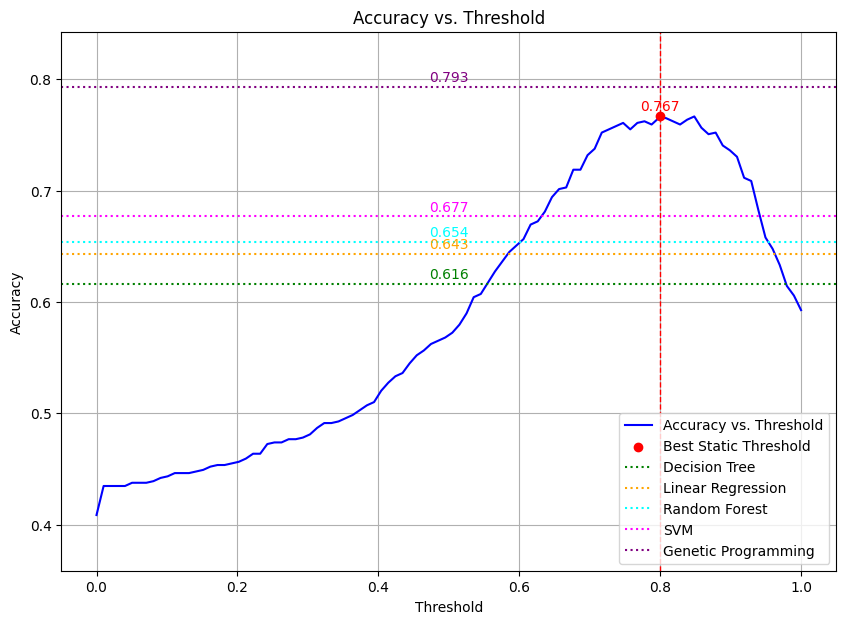

In [398]:
def best_pareto_solution(hof_updated, X_test, Y_test, SIMILARITY_test, toolbox, classifiers_accuracies):
    best_func = toolbox.compile(expr=hof_updated[0])
    test_threshold_predictions = [evolved_threshold(best_func(*x)) for x in X_test]
    test_acc, TP, TN, FP, FN = predicted_threshold_accuracy(SIMILARITY_test, test_threshold_predictions, Y_test)

    static_thresholds = np.linspace(0, 1, 100)  # Thresholds from 0 to 1
    accuracies = [specific_threshold_accuracy(SIMILARITY_test, t, Y_test) for t in static_thresholds]
    best_threshold, best_accuracy = best_possible_threshold(SIMILARITY_test, Y_test, increment=0.01)

    plt.figure(figsize=(10, 7))
    plt.plot(static_thresholds, accuracies, label='Accuracy vs. Threshold', color='blue')
    plt.scatter(best_threshold, best_accuracy, color='red', label=f'Best Static Threshold', zorder=5)
    plt.axvline(best_threshold, color='red', linestyle='--', linewidth=1)
    plt.text(best_threshold, best_accuracy + 0.005, f'{best_accuracy:.3f}', ha='center', color='red', fontsize=10)

    classifier_colors = ['green', 'orange', 'cyan', 'magenta', "purple"]
    for i, (name, acc) in enumerate(classifiers_accuracies.items()):
        plt.axhline(acc, color=classifier_colors[i % len(classifier_colors)], linestyle=':', label=f'{name}')
        plt.text(0.5, acc + 0.005, f'{acc:.3f}', color=classifier_colors[i % len(classifier_colors)], ha='center', fontsize=10)

    min_y = min([test_acc, min(accuracies), min(classifiers_accuracies.values())]) - 0.05
    max_y = max([test_acc, max(accuracies), max(classifiers_accuracies.values())]) + 0.05
    plt.ylim(max(0, min_y), min(1, max_y))
    plt.xlabel('Threshold')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs. Threshold')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    
    
best_pareto_solution(hof, X_test, Y_test, SIMILARITY_test, toolbox, classifiers_accuracies)


In [399]:
# Evaluate missclassified examples
best_func = toolbox.compile(expr=hof_updated[0])
[sol for (sol, acc, len_ind) in solutions_with_accuracy]
test_threshold_predictions = np.array([evolved_threshold(best_func(*x)) for x in X_test])
predicted_labels = np.array([1 if sim >= threshold else 0 for sim, threshold in zip(SIMILARITY_test, test_threshold_predictions)])
indexes = np.where((Y_test == 1) & (predicted_labels == 0))[0]
similarity_values = SIMILARITY_test[indexes]
thresholds = test_threshold_predictions[indexes]
misclassified_indexes = np.where(Y_test != predicted_labels)[0]

# Look at details of misclassified samples
for idx in misclassified_indexes[:50]:  # Limit to first 10 for inspection
    print(f"Index: {idx}")
    print(f"Question1: {df.iloc[test_indices[idx]]['question1']}")
    print(f"Question2: {df.iloc[test_indices[idx]]['question2']}")
    print(f"True Label: {Y_test[idx]}, Predicted Label: {predicted_labels[idx]}")
    print(f"Similarity: {SIMILARITY_test[idx]}, Threshold: {test_threshold_predictions[idx]}")
    print("-" * 50)


Index: 2
Question1: What is your view on the recent demonetization in India?
Question2: What are your views on demonetization of ₹500 & ₹1000 notes in India?
True Label: 1, Predicted Label: 0
Similarity: 0.7378024458885193, Threshold: 0.85
--------------------------------------------------
Index: 3
Question1: How much will the price of gold fall?
Question2: Why is the price of gold falling?
True Label: 0, Predicted Label: 1
Similarity: 0.8701680898666382, Threshold: 0.81
--------------------------------------------------
Index: 5
Question1: How can I draw myself as an anime character?
Question2: How do I draw my anime character?
True Label: 1, Predicted Label: 0
Similarity: 0.8858256340026855, Threshold: 0.94
--------------------------------------------------
Index: 7
Question1: What are some popular method to do suicide?
Question2: Is there some painless way to suicide?
True Label: 1, Predicted Label: 0
Similarity: 0.8183723092079163, Threshold: 0.86
----------------------------------